[0.33333333 0.16666667 0.16666667 0.33333333]
Distance Cost Matrix:
 [[1.         2.23606798 2.23606798]
 [1.         1.         2.23606798]
 [2.23606798 2.23606798 1.        ]
 [8.06225775 7.         8.06225775]]
Optimal Transport Plan:
 [[ 0.33 -0.    0.  ]
 [ 0.    0.17  0.  ]
 [-0.   -0.    0.17]
 [-0.    0.17  0.17]]
The shape of the OT plan matrix is:
  (4, 3)


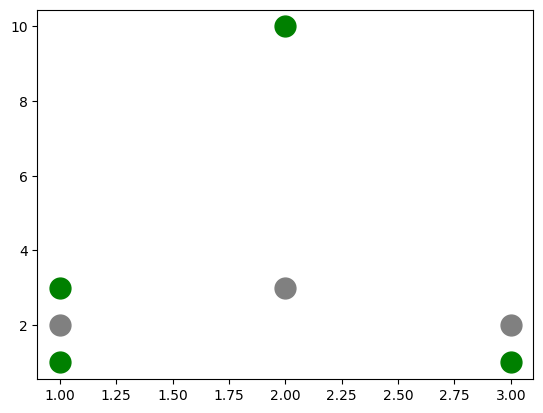

In [ ]:
import cvxpy as cp
import numpy as np
from scipy.spatial import distance_matrix
import matplotlib.pyplot as plt

p = cp.Variable((4,3))

# cost matrix
# Define coordinates
origins = np.array([[1, 1],[1, 3],[3, 1], [2,10]])
destinations = np.array([[1,2],[2,3],[3,2]])

# source masses
source_masses = np.array([1, 1/2, 1/2, 1])/3
print(source_masses)
# destination masses
destination_masses = np.ones(3)/3

# Generate Euclidean distance cost matrix
# Rows represent origins, columns represent destinations
cost_matrix = distance_matrix(origins, destinations)
print("Distance Cost Matrix:\n", cost_matrix)

# want the frobenius inner product
hadamard = cp.multiply(cost_matrix, p)
loss = cp.sum(hadamard)
prob = cp.Problem(cp.Minimize(loss), [cp.sum(p, axis=0) ==destination_masses, cp.sum(p, axis=1) == source_masses, p >= 0])
prob.solve(solver=cp.CLARABEL)
print("Optimal Transport Plan:\n", p.value.round(2))
print("The shape of the OT plan matrix is:\n ",p.value.shape)

plt.plot(origins[:,0], origins[:,1], marker='o', markersize=15, linestyle='', color="Green")
plt.plot(destinations[:,0], destinations[:,1], marker='o', markersize=15, linestyle='', color="Grey")
plt.show()

In [ ]:
# EXPLANATION
# the plan is diagonal because the first entry of the origins 
# array goes to the first entry of the destinations array. 

# the number of rows in the OT plan (array) corresponds to the number of origins.
# number of columns corresponds to number of destinations.
# so the OT plan array is (o,d).

# first row of the distance cost matrix is the distance
# from the first element of the origins array to each of the elements of the destinations array.